# Machine Learning Modelling

This notebook provides normal steps in machine learning modelling: dataset construction, machine learning modelling, training, validation and evaluation. This is the last notebook in the machine learning pipeline. Preprocessing, exploration and data preparation are performed in notebook 1-3. 

The notebook includes the following: 
- Constructing different datasets 
- Defining pipelines (including feature preprocessing, cross-validation, and hyperparameter tuning)
- Fitting classifiers on training sets
- Evaluating the best models per classifier (F1-score, classification report, confusion matrix) 
- Applying the overall best model to subsets of variants within oncogenic genes 


## Import Libraries

In [1]:
# import general python packages 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

# import classfiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# import model selection and preprocessing tools 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, f1_score


## Import Data 

In [2]:
X_train = pd.read_csv("data/X_train.csv", sep=",", low_memory= False) 
X_test = pd.read_csv("data/X_test.csv", sep=",", low_memory=False)

y_train = pd.read_csv("data/y_train.csv", sep=",", low_memory=False) 
y_test = pd.read_csv("data/y_test.csv", sep=",", low_memory=False) 

# Check lengths 
print(f"X: {len(X_train)}, y: {len(y_train)}")

X: 1524, y: 1524


## Define the Datasets

- **Dataset 1:** Full feature set. Remove rows with missing values in Polyphen_Score and SIFT_Score.
- **Dataset 2:** Exclude the features 'Polyphen_Score','SIFT_Score'. 
- **Dataset 3:** Exclude the feature 'Consequence'. Remove missing values in 'Polyphen_Score' and 'SIFT_Score'.
- **Dataset 4:** Exclude the features 'Polyphen_Score', 'SIFT_Score', 'Consequence'.
- **Dataset 5:** Full feature set. Impute -1 in rows with missing Polyphen and SIFT scores. 

## Create Datasets

### Define columns to handle

In [3]:
# Define columns to handle 
score_columns = ["Polyphen_Score", "SIFT_Score"] 
consequence_column = ["Consequence"]

### Check column names

In [4]:
# Check column names
print(X_train.columns.tolist())

['Hugo_Symbol', 'Consequence', 'Variant_Type', 'has_gnomAD_AF', 'Polyphen_Score', 'SIFT_Score', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'ncg_tsg', 'ncg_oncogene', 'is_null_var_tsg', 'gnomAD_AF_log']


### Dataset 1

In [5]:
# Dataset 1: Full feature set, remove rows with missing values 
mask_train = X_train[score_columns].notna().all(axis=1) 
mask_test = X_test[score_columns].notna().all(axis=1) 

X_train_1 = X_train[mask_train].copy()
y_train_1 = y_train[mask_train].copy()

X_test_1 = X_test[mask_test].copy()
y_test_1 = y_test[mask_test].copy()

# Drop Hugo_Symbol 
X_train_1 = X_train_1.drop(columns="Hugo_Symbol")
X_test_1 = X_test_1.drop(columns="Hugo_Symbol") 

# control that no rows has missing values 
print(f"X_train_1 has {(X_train_1.isna().sum().sum())} missing values.") 

X_train_1 has 0 missing values.


In [6]:
print("The five first rows of X_train_1:")  
display(X_train_1.head())

The five first rows of X_train_1:


,Consequence,Variant_Type,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,ncg_tsg,ncg_oncogene,is_null_var_tsg,gnomAD_AF_log
0,missense_variant,SNP,False,0.908,0.00,False,False,0,False,0,True,False,False,-6.000000
1,missense_variant,SNP,True,0.007,0.08,False,True,1,False,0,False,True,False,-5.301436
2,missense_variant,SNP,False,0.087,0.31,False,False,0,False,0,False,True,False,-6.000000
3,missense_variant,SNP,False,0.497,0.01,False,True,1,True,1,False,True,False,-6.000000
4,missense_variant,SNP,True,0.586,0.01,False,False,0,True,1,False,True,False,-5.047830


### Dataset 2

In [7]:
# Dataset 2: Exlude the features 'Polyphen_Score','SIFT_Score'
cols_to_drop_2 = score_columns 
X_train_2 = X_train.drop(columns=cols_to_drop_2)
X_test_2 = X_test.drop(columns=cols_to_drop_2)
y_train_2 = y_train.copy()
y_test_2 = y_test.copy()

# Drop Hugo_Symbol 
X_train_2 = X_train_2.drop(columns="Hugo_Symbol")
X_test_2 = X_test_2.drop(columns="Hugo_Symbol") 

# Check column names in the new dataset 
print(X_train_2.columns.tolist())

# control that no rows has missing values 
print(f"X_train_2 has {(X_train_2.isna().sum().sum())} missing values.")

['Consequence', 'Variant_Type', 'has_gnomAD_AF', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'ncg_tsg', 'ncg_oncogene', 'is_null_var_tsg', 'gnomAD_AF_log']
X_train_2 has 0 missing values.


In [8]:
print("The five first rows of X_train_2:")  
display(X_train_2.head())

The five first rows of X_train_2:


,Consequence,Variant_Type,has_gnomAD_AF,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,ncg_tsg,ncg_oncogene,is_null_var_tsg,gnomAD_AF_log
0,missense_variant,SNP,False,False,False,0,False,0,True,False,False,-6.000000
1,missense_variant,SNP,True,False,True,1,False,0,False,True,False,-5.301436
2,missense_variant,SNP,False,False,False,0,False,0,False,True,False,-6.000000
3,missense_variant,SNP,False,False,True,1,True,1,False,True,False,-6.000000
4,missense_variant,SNP,True,False,False,0,True,1,False,True,False,-5.047830


### Dataset 3 

In [9]:
# Dataset 3: exclude the column 'Consequence', remove missing values in Polyphen and SIFT. 
mask_train = X_train[score_columns].notna().all(axis=1)
mask_test = X_test[score_columns].notna().all(axis=1)

X_train_3 = X_train[mask_train].drop(columns=consequence_column)
X_test_3 = X_test[mask_test].drop(columns=consequence_column)
y_train_3 = y_train[mask_train].copy()
y_test_3 = y_test[mask_test].copy()

# Drop Hugo_Symbol 
X_train_3 = X_train_3.drop(columns="Hugo_Symbol")
X_test_3 = X_test_3.drop(columns="Hugo_Symbol") 

# control column names
print(X_train_3.columns.tolist())

# control that no rows has missing values 
print(f"X_train_3 has {(X_train_3.isna().sum().sum())} missing values.")

['Variant_Type', 'has_gnomAD_AF', 'Polyphen_Score', 'SIFT_Score', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'ncg_tsg', 'ncg_oncogene', 'is_null_var_tsg', 'gnomAD_AF_log']
X_train_3 has 0 missing values.


In [10]:
print("The five first rows of X_train_3:")  
display(X_train_3.head())

The five first rows of X_train_3:


,Variant_Type,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,ncg_tsg,ncg_oncogene,is_null_var_tsg,gnomAD_AF_log
0,SNP,False,0.908,0.00,False,False,0,False,0,True,False,False,-6.000000
1,SNP,True,0.007,0.08,False,True,1,False,0,False,True,False,-5.301436
2,SNP,False,0.087,0.31,False,False,0,False,0,False,True,False,-6.000000
3,SNP,False,0.497,0.01,False,True,1,True,1,False,True,False,-6.000000
4,SNP,True,0.586,0.01,False,False,0,True,1,False,True,False,-5.047830


### Dataset 4 

In [11]:
# Dataset 4: Exclude the features 'Polyphen_Score', 'SIFT_Score', 'Consequence'.
cols_to_drop_4 = score_columns + consequence_column

X_train_4 = X_train.drop(columns=cols_to_drop_4)
X_test_4 = X_test.drop(columns=cols_to_drop_4)
y_train_4 = y_train.copy()
y_test_4 = y_test.copy()

# Drop Hugo_Symbol 
X_train_4 = X_train_4.drop(columns="Hugo_Symbol")
X_test_4 = X_test_4.drop(columns="Hugo_Symbol") 

# control column names
print(X_train_4.columns.tolist())

# control that no rows has missing values 
print(f"X_train_4 has {(X_train_4.isna().sum().sum())} missing values.")  

['Variant_Type', 'has_gnomAD_AF', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'ncg_tsg', 'ncg_oncogene', 'is_null_var_tsg', 'gnomAD_AF_log']
X_train_4 has 0 missing values.


In [12]:
print("The five first rows of X_train_4:")  
display(X_train_4.head())

The five first rows of X_train_4:


,Variant_Type,has_gnomAD_AF,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,ncg_tsg,ncg_oncogene,is_null_var_tsg,gnomAD_AF_log
0,SNP,False,False,False,0,False,0,True,False,False,-6.000000
1,SNP,True,False,True,1,False,0,False,True,False,-5.301436
2,SNP,False,False,False,0,False,0,False,True,False,-6.000000
3,SNP,False,False,True,1,True,1,False,True,False,-6.000000
4,SNP,True,False,False,0,True,1,False,True,False,-5.047830


### Dataset 5

In [13]:
# Dataset 5: Full feature set. Impute -1 in rows with missing SIFT and Polyphen scores 
X_train_5 = X_train.copy()
X_test_5 = X_test.copy()

impute_cols = ['SIFT_Score', 'Polyphen_Score']
X_train_5[impute_cols] = X_train_5[impute_cols].fillna(-1)
X_test_5[impute_cols] = X_test_5[impute_cols].fillna(-1)

y_train_5 = y_train.copy()
y_test_5 = y_test.copy()

# Drop Hugo_Symbol 
X_train_5 = X_train_5.drop(columns="Hugo_Symbol")
X_test_5 = X_test_5.drop(columns="Hugo_Symbol") 

In [14]:
# Check for missing values 
print(f"X_train_5 has {X_train_5.isna().sum().sum()} missing values.")

X_train_5 has 0 missing values.


In [15]:
print("The five first rows of X_train_5")  
display(X_train_5.head())

The five first rows of X_train_5


,Consequence,Variant_Type,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,ncg_tsg,ncg_oncogene,is_null_var_tsg,gnomAD_AF_log
0,missense_variant,SNP,False,0.908,0.00,False,False,0,False,0,True,False,False,-6.000000
1,missense_variant,SNP,True,0.007,0.08,False,True,1,False,0,False,True,False,-5.301436
2,missense_variant,SNP,False,0.087,0.31,False,False,0,False,0,False,True,False,-6.000000
3,missense_variant,SNP,False,0.497,0.01,False,True,1,True,1,False,True,False,-6.000000
4,missense_variant,SNP,True,0.586,0.01,False,False,0,True,1,False,True,False,-5.047830


## Define the Pipelines

In [16]:
categorical_feat = ["Variant_Type", "Consequence"]
binary_feat = ["IN_DOMAIN", "has_gnomAD_AF", "IN_FUNC_SITE", "In_Hotspot", "ncg_oncogene", "ncg_tsg", "is_null_var_tsg"]
numerical_feat = ["gnomAD_AF_log", "Polyphen_Score", "SIFT_Score", "n_protein_domains", "n_func_sites"]

def create_pipeline(df, model, categorical_feat, binary_feat, numerical_feat): 
  """
  Creates ML-pipeline based on categorical columns in df, 
  for the chosen ML classifier. 
  """
  existing_cat = [c for c in categorical_feat if c in df.columns]
  existing_bin = [c for c in binary_feat if c in df.columns]
  existing_num = [c for c in numerical_feat if c in df.columns]

  preprocessor = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), existing_num),
            ('bin', 'passthrough', existing_bin), 
            ('cat', OneHotEncoder(handle_unknown='ignore'), existing_cat)
        ])
  
  return Pipeline([
    ('preprocessor', preprocessor),
    ('clf', model)
  ])

In [17]:
# Define the logistic regression pipeline
pipe_logistic1 = create_pipeline(X_train_1, LogisticRegression(max_iter=5000), categorical_feat, binary_feat, numerical_feat)
pipe_logistic2 = create_pipeline(X_train_2, LogisticRegression(max_iter=5000), categorical_feat, binary_feat, numerical_feat)
pipe_logistic3 = create_pipeline(X_train_3, LogisticRegression(max_iter=5000), categorical_feat, binary_feat, numerical_feat)
pipe_logistic4 = create_pipeline(X_train_4, LogisticRegression(max_iter=5000), categorical_feat, binary_feat, numerical_feat)
pipe_logistic5 = create_pipeline(X_train_5, LogisticRegression(max_iter=5000), categorical_feat, binary_feat, numerical_feat)

# Define the random forest pipeline
pipe_rf1 = create_pipeline(X_train_1, RandomForestClassifier(random_state=1), categorical_feat, binary_feat, numerical_feat) 
pipe_rf2 = create_pipeline(X_train_2, RandomForestClassifier(random_state=1), categorical_feat, binary_feat, numerical_feat) 
pipe_rf3 = create_pipeline(X_train_3, RandomForestClassifier(random_state=1), categorical_feat, binary_feat, numerical_feat) 
pipe_rf4 = create_pipeline(X_train_4, RandomForestClassifier(random_state=1), categorical_feat, binary_feat, numerical_feat) 
pipe_rf5 = create_pipeline(X_train_5, RandomForestClassifier(random_state=1), categorical_feat, binary_feat, numerical_feat) 


# Define the xgboost pipeline 
pipe_xgb1 = create_pipeline(X_train_1, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat, binary_feat, numerical_feat)
pipe_xgb2 = create_pipeline(X_train_2, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat, binary_feat, numerical_feat)
pipe_xgb3 = create_pipeline(X_train_3, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat, binary_feat, numerical_feat)
pipe_xgb4 = create_pipeline(X_train_4, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat, binary_feat, numerical_feat)
pipe_xgb5 = create_pipeline(X_train_5, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat, binary_feat, numerical_feat)

## **ML Modeling**

## Linear Regression Model

### Define CV-strategy, pipeline, and hyperparameters to test 

In [18]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

logistic1 = GridSearchCV(
  estimator=pipe_logistic1, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear'],
              'clf__class_weight': ['balanced']
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic2 = GridSearchCV(
  estimator=pipe_logistic2, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear'],
              'clf__class_weight': ['balanced']
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic3 = GridSearchCV(
  estimator=pipe_logistic3, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear'],
              'clf__class_weight': ['balanced']
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic4 = GridSearchCV(
  estimator=pipe_logistic4, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear'],
              'clf__class_weight': ['balanced']
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

logistic5 = GridSearchCV(
  estimator=pipe_logistic5, 
  param_grid={'clf__C': [0.001, 0.1,1,10],
              'clf__l1_ratio': [0,1],
              'clf__solver': ['liblinear'],
              'clf__class_weight': ['balanced']
              },
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)


### Fit logistic model to all training data 

In [19]:
logistic1 = logistic1.fit(X_train_1, y_train_1.values.ravel())

print(f"The best F1-score (Macro) for dataset 1: {logistic1.best_score_}")
print(f"The best hyperparameters: {logistic1.best_params_}")

logistic2 = logistic2.fit(X_train_2, y_train_2.values.ravel())

print(f"The best F1-score (Macro) for dataset 2: {logistic2.best_score_}")
print(f"The best hyperparameters: {logistic2.best_params_}")

logistic3 = logistic3.fit(X_train_3, y_train_3.values.ravel())

print(f"The best F1-score (Macro) for dataset 3: {logistic3.best_score_}")
print(f"The best hyperparameters: {logistic3.best_params_}")

logistic4 = logistic4.fit(X_train_4, y_train_4.values.ravel())

print(f"The best F1-score (Macro) for dataset 4: {logistic4.best_score_}")
print(f"The best hyperparameters: {logistic4.best_params_}")

logistic5 = logistic5.fit(X_train_5, y_train_5.values.ravel())

print(f"The best F1-score (Macro) for dataset 5: {logistic5.best_score_}")
print(f"The best hyperparameters: {logistic5.best_params_}")

The best F1-score (Macro) for dataset 1: 0.7508644150666565
The best hyperparameters: {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0, 'clf__solver': 'liblinear'}
The best F1-score (Macro) for dataset 2: 0.7320363674055935
The best hyperparameters: {'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0, 'clf__solver': 'liblinear'}
The best F1-score (Macro) for dataset 3: 0.7517092207341263
The best hyperparameters: {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0, 'clf__solver': 'liblinear'}
The best F1-score (Macro) for dataset 4: 0.7290924871715129
The best hyperparameters: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0, 'clf__solver': 'liblinear'}
The best F1-score (Macro) for dataset 5: 0.743706925175456
The best hyperparameters: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0, 'clf__solver': 'liblinear'}


### Evaluate Model Performance (Dataset 1)

Evaluates model performance on dataset 1, since this performed best on the training data. 

Dataset 1:
Full feature set. Remove rows with missing values in Polyphen_Score and SIFT_Score.

In [20]:
# Predict classes for dataset 1 
y_pred_1 = logistic1.predict(X_test_1)

# Predict probabilities
y_probs_1 = logistic1.predict_proba(X_test_1)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_1, y_pred_1, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_1))

Test F1-score (Macro): 0.7374

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.81      0.77       162
           1       0.77      0.66      0.71       150

    accuracy                           0.74       312
   macro avg       0.74      0.74      0.74       312
weighted avg       0.74      0.74      0.74       312



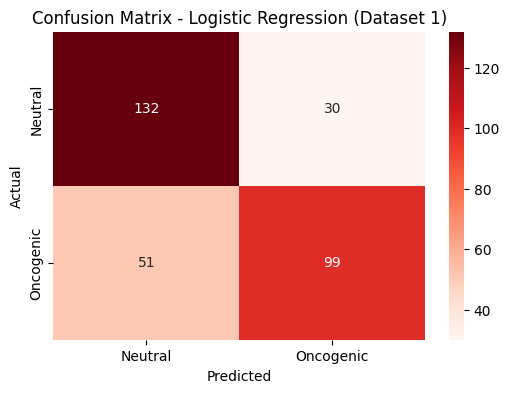

In [21]:
cm = confusion_matrix(y_test_1, y_pred_1)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Dataset 1)')
plt.show()

### Feature Coeffisients for the Logistic Regression Model

In [22]:
best_model = logistic1.best_estimator_  

coefficients = pd.Series(
    best_model.named_steps['clf'].coef_[0],
    index=best_model.named_steps['preprocessor'].get_feature_names_out()
).sort_values(key=abs, ascending=False) 

print(coefficients)

bin__In_Hotspot                                            2.562681
num__gnomAD_AF_log                                        -0.771654
num__Polyphen_Score                                        0.663317
bin__IN_DOMAIN                                            -0.395004
cat__Variant_Type_SNP                                      0.351495
bin__IN_FUNC_SITE                                         -0.345768
bin__has_gnomAD_AF                                        -0.238130
bin__ncg_oncogene                                         -0.232736
cat__Variant_Type_TNP                                     -0.199952
num__n_protein_domains                                    -0.149585
cat__Variant_Type_DNP                                     -0.120724
num__SIFT_Score                                           -0.109163
bin__ncg_tsg                                               0.105047
num__n_func_sites                                          0.038932
cat__Consequence_missense_variant,splice_region_

## Random Forest Model

### Define CV-strategy, pipeline, and hyperparameters to test 

In [23]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

param_dist = {
    'clf__n_estimators': [100, 200, 300, 400, 500],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__max_depth': [10, 20, 30, None],
    'clf__criterion': ['gini', 'entropy'],
    'clf__min_samples_split': [2, 5, 10, 12],
    'clf__min_samples_leaf': [1, 2, 4, 6]
}

rf1 = RandomizedSearchCV(
    estimator=pipe_rf1,
    param_distributions=param_dist,
    n_iter=20,           
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf2 = RandomizedSearchCV(
    estimator=pipe_rf2,
    param_distributions=param_dist,
    n_iter=20,           
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf3 = RandomizedSearchCV(
    estimator=pipe_rf3,
    param_distributions=param_dist,
    n_iter=20,           
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf4 = RandomizedSearchCV(
    estimator=pipe_rf4,
    param_distributions=param_dist,
    n_iter=20,           
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf5 = RandomizedSearchCV(
    estimator=pipe_rf5,
    param_distributions=param_dist,
    n_iter=20,           
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

### Fit random forest model to all training data 

In [24]:
rf1 = rf1.fit(X_train_1, y_train_1.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 1: {rf1.best_score_}")
print(f"The best hyperparameters: {rf1.best_params_}")


rf2 = rf2.fit(X_train_2, y_train_2.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 2: {rf2.best_score_}")
print(f"The best hyperparameters: {rf2.best_params_}")


rf3 = rf3.fit(X_train_3, y_train_3.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 3: {rf3.best_score_}")
print(f"The best hyperparameters: {rf3.best_params_}")


rf4 = rf4.fit(X_train_4, y_train_4.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 4: {rf4.best_score_}")
print(f"The best hyperparameters: {rf4.best_params_}")


rf5 = rf5.fit(X_train_5, y_train_5.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 5: {rf5.best_score_}")
print(f"The best hyperparameters: {rf5.best_params_}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits
The best F1-score (Macro) for dataset 1: 0.7627148588425762
The best hyperparameters: {'clf__n_estimators': 500, 'clf__min_samples_split': 12, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': None, 'clf__criterion': 'entropy'}
Fitting 10 folds for each of 20 candidates, totalling 200 fits
The best F1-score (Macro) for dataset 2: 0.7641401837012319
The best hyperparameters: {'clf__n_estimators': 500, 'clf__min_samples_split': 12, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': None, 'clf__criterion': 'entropy'}
Fitting 10 folds for each of 20 candidates, totalling 200 fits
The best F1-score (Macro) for dataset 3: 0.7651282153998477
The best hyperparameters: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 4, 'clf__max_features': 'sqrt', 'clf__max_depth': None, 'clf__criterion': 'gini'}
Fitting 10 folds for each of 20 candidates, totalling 20

### Evaluate Model Performance (Dataset 5)

Evaluates model performance on dataset 5. 

Dataset 5: Full feature set. Impute -1 in rows with missing Polyphen and SIFT scores. 

In [25]:
# Predict classes for dataset 5
y_pred_5 = rf5.predict(X_test_5)

# Predict probabilities
y_probs_5 = rf5.predict_proba(X_test_5)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_5, y_pred_5, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_5, y_pred_5))

Test F1-score (Macro): 0.7873

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.81      0.78       172
           1       0.83      0.77      0.80       210

    accuracy                           0.79       382
   macro avg       0.79      0.79      0.79       382
weighted avg       0.79      0.79      0.79       382



Text(0.5, 1.0, 'Confusion Matrix - Random Forest (Dataset 5)')

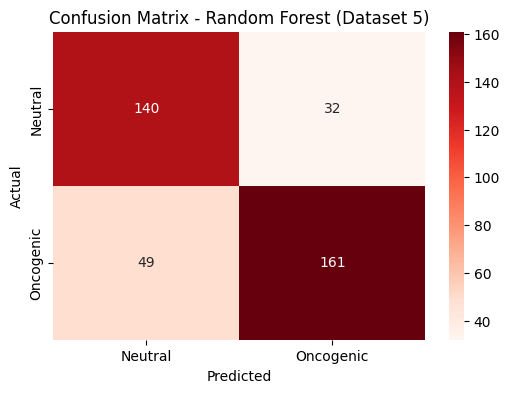

In [26]:
cm = confusion_matrix(y_test_5, y_pred_5)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (Dataset 5)')

### Feature importances Random Forest 

In [27]:
# Define the best model 
best_model = rf5.best_estimator_

# Get feature names 
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

bin__In_Hotspot                                                    0.216734
num__Polyphen_Score                                                0.156224
num__SIFT_Score                                                    0.151066
num__gnomAD_AF_log                                                 0.093523
bin__has_gnomAD_AF                                                 0.039896
num__n_func_sites                                                  0.036968
cat__Variant_Type_DEL                                              0.034238
bin__ncg_tsg                                                       0.031683
bin__IN_FUNC_SITE                                                  0.030731
cat__Variant_Type_SNP                                              0.029958
bin__ncg_oncogene                                                  0.028561
cat__Consequence_missense_variant                                  0.027575
bin__IN_DOMAIN                                                     0.023516
num__n_prote

## XGBoost Model

### Define CV-strategy, pipeline, and hyperparameters to test 

In [28]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) 

xgb_param_dist = {
    'clf__n_estimators': [100, 300, 500],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [3, 5, 7, 9],
    'clf__subsample': [0.7, 0.8, 0.9],
    'clf__colsample_bytree': [0.7, 0.8, 0.9],
    'clf__gamma': [0, 0.1, 0.5, 1],
    'clf__scale_pos_weight': [0.7,0.8,0.9,1,3,5] 
}

xgb1 = RandomizedSearchCV(
        estimator=pipe_xgb1,
        param_distributions=xgb_param_dist,
        n_iter=20,           
        scoring='f1_macro',
        cv=cv_strategy,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

xgb2 = RandomizedSearchCV(
        estimator=pipe_xgb2,
        param_distributions=xgb_param_dist,
        n_iter=20,           
        scoring='f1_macro',
        cv=cv_strategy,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

xgb3 = RandomizedSearchCV(
        estimator=pipe_xgb3,
        param_distributions=xgb_param_dist,
        n_iter=20,           
        scoring='f1_macro',
        cv=cv_strategy,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

xgb4 = RandomizedSearchCV(
        estimator=pipe_xgb4,
        param_distributions=xgb_param_dist,
        n_iter=20,           
        scoring='f1_macro',
        cv=cv_strategy,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

xgb5 = RandomizedSearchCV(
        estimator=pipe_xgb5,
        param_distributions=xgb_param_dist,
        n_iter=20,           
        scoring='f1_macro',
        cv=cv_strategy,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )


In [29]:
xgb1 = xgb1.fit(X_train_1, y_train_1.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 1: {xgb1.best_score_}")
print(f"The best hyperparameters: {xgb1.best_params_}")


xgb2 = xgb2.fit(X_train_2, y_train_2.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 2: {xgb2.best_score_}")
print(f"The best hyperparameters: {xgb2.best_params_}")


xgb3 = xgb3.fit(X_train_3, y_train_3.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 3: {xgb3.best_score_}")
print(f"The best hyperparameters: {xgb3.best_params_}")


xgb4 = xgb4.fit(X_train_4, y_train_4.values.ravel()) 


print(f"The best F1-score (Macro) for dataset 4: {xgb4.best_score_}")
print(f"The best hyperparameters: {xgb4.best_params_}")


xgb5 = xgb5.fit(X_train_5, y_train_5.values.ravel()) 

print(f"The best F1-score (Macro) for dataset 5: {xgb5.best_score_}")
print(f"The best hyperparameters: {xgb5.best_params_}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits
The best F1-score (Macro) for dataset 1: 0.7714710700396101
The best hyperparameters: {'clf__subsample': 0.7, 'clf__scale_pos_weight': 0.8, 'clf__n_estimators': 100, 'clf__max_depth': 7, 'clf__learning_rate': 0.05, 'clf__gamma': 0, 'clf__colsample_bytree': 0.8}
Fitting 10 folds for each of 20 candidates, totalling 200 fits
The best F1-score (Macro) for dataset 2: 0.7639551627126612
The best hyperparameters: {'clf__subsample': 0.9, 'clf__scale_pos_weight': 0.9, 'clf__n_estimators': 500, 'clf__max_depth': 9, 'clf__learning_rate': 0.01, 'clf__gamma': 0, 'clf__colsample_bytree': 0.9}
Fitting 10 folds for each of 20 candidates, totalling 200 fits
The best F1-score (Macro) for dataset 3: 0.769603980712948
The best hyperparameters: {'clf__subsample': 0.7, 'clf__scale_pos_weight': 0.9, 'clf__n_estimators': 500, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__gamma': 0, 'clf__colsample_bytree': 0.9}
Fitting 10 folds for each 

### Evaluate Model Performance (Dataset 5)

Evaluates model performance on dataset 5. Dataset 1 performs slightly better on the training data (0.003), but was trained on a smaller sample size. Since dataset 5 retains more data, this will be used for evaluation on test data. 

Dataset 5: Full feature set. Impute -1 in rows with missing Polyphen and SIFT scores. 

In [30]:
# Predict classes for dataset 5
y_pred_5 = xgb5.predict(X_test_5)

# Predict probabilities
y_probs_5 = xgb5.predict_proba(X_test_5)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_5, y_pred_5, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_5, y_pred_5))

Test F1-score (Macro): 0.7718

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.81      0.76       172
           1       0.83      0.74      0.78       210

    accuracy                           0.77       382
   macro avg       0.77      0.78      0.77       382
weighted avg       0.78      0.77      0.77       382



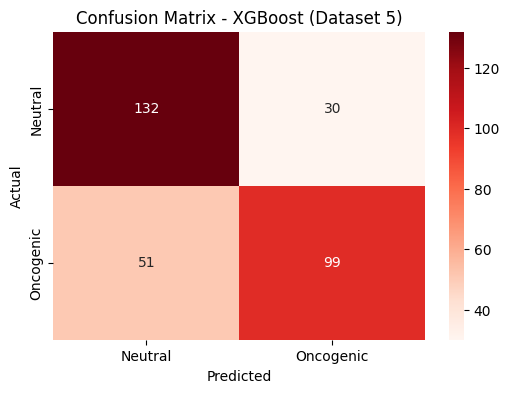

In [31]:
cm = confusion_matrix(y_test_1, y_pred_1)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (Dataset 5)')
plt.show()

### Feature Importances XGBoost

In [32]:
# Define the best model 
best_model = xgb1.best_estimator_

# Get feature names 
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

bin__In_Hotspot                                            0.582825
num__gnomAD_AF_log                                         0.040181
bin__has_gnomAD_AF                                         0.039808
bin__ncg_oncogene                                          0.038102
num__SIFT_Score                                            0.035507
num__n_protein_domains                                     0.035171
num__Polyphen_Score                                        0.031444
bin__IN_DOMAIN                                             0.028420
bin__ncg_tsg                                               0.028251
bin__IN_FUNC_SITE                                          0.026211
cat__Consequence_missense_variant                          0.026153
cat__Consequence_missense_variant,splice_region_variant    0.023361
cat__Variant_Type_SNP                                      0.023279
num__n_func_sites                                          0.023147
cat__Variant_Type_DNP                           

## **Run Best Model (rf5) on Selected Top Oncogenic Genes**

## TP53 dataset 

### Define the data

In [33]:
X_train_TP53 = X_train[X_train["Hugo_Symbol"] == 'TP53']
X_test_TP53 = X_test[X_test["Hugo_Symbol"] == 'TP53']

impute_cols = ['SIFT_Score', 'Polyphen_Score']
X_train_TP53[impute_cols] = X_train_TP53[impute_cols].fillna(-1)
X_test_TP53[impute_cols] = X_test_TP53[impute_cols].fillna(-1)

X_train_TP53 = X_train_TP53.drop(columns="Hugo_Symbol")
X_test_TP53 = X_test_TP53.drop(columns="Hugo_Symbol")

# Filter y to match TP53 indices
y_train_TP53 = y_train.loc[X_train_TP53.index]
y_test_TP53 = y_test.loc[X_test_TP53.index]

### Fit model to data

In [34]:
rf5_TP53 = rf5.fit(X_train_TP53, y_train_TP53.values.ravel()) 

print(rf5_TP53.best_score_)
print(rf5_TP53.best_params_)

print(f"The best F1-score (Macro) for the TP53 dataset: {rf5_TP53.best_score_}")
print(f"The best hyperparameters: {rf5_TP53.best_params_}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits
0.705
{'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 4, 'clf__max_features': 'log2', 'clf__max_depth': None, 'clf__criterion': 'entropy'}
The best F1-score (Macro) for the TP53 dataset: 0.705
The best hyperparameters: {'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 4, 'clf__max_features': 'log2', 'clf__max_depth': None, 'clf__criterion': 'entropy'}


### Predict classes and make classification report

In [35]:
# Predict classes for the TP53 dataset
y_pred_TP53 = rf5_TP53.predict(X_test_TP53)

# Predict probabilities
y_probs_TP53 = rf5_TP53.predict_proba(X_test_TP53)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_TP53, y_pred_TP53, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_TP53, y_pred_TP53))

Test F1-score (Macro): 0.3125

Classification Report:
              precision    recall  f1-score   support

           0       0.45      1.00      0.62         5
           1       0.00      0.00      0.00         6

    accuracy                           0.45        11
   macro avg       0.23      0.50      0.31        11
weighted avg       0.21      0.45      0.28        11



/home/anekl/git/master/machine_learning_pipeline/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/anekl/git/master/machine_learning_pipeline/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/anekl/git/master/machine_learning_pipeline/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

### Create confusion matrix

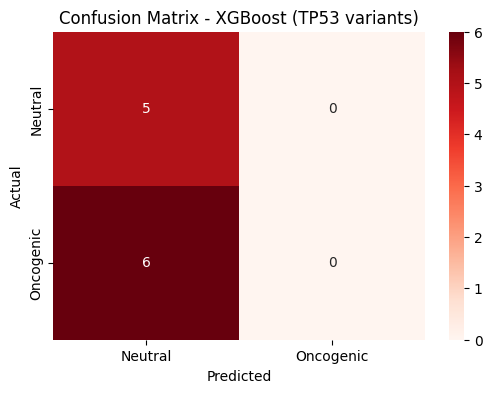

In [36]:
cm = confusion_matrix(y_test_TP53, y_pred_TP53)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (TP53 variants)')
plt.show()

### Find feature importances

In [37]:
# Define the best model 
best_model_TP53 = rf5_TP53.best_estimator_

# Get feature names 
feature_names = best_model_TP53.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model_TP53.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

num__Polyphen_Score                  0.450185
bin__In_Hotspot                      0.291192
num__SIFT_Score                      0.250450
bin__has_gnomAD_AF                   0.008174
num__gnomAD_AF_log                   0.000000
num__n_protein_domains               0.000000
bin__IN_DOMAIN                       0.000000
num__n_func_sites                    0.000000
bin__IN_FUNC_SITE                    0.000000
bin__ncg_oncogene                    0.000000
bin__ncg_tsg                         0.000000
bin__is_null_var_tsg                 0.000000
cat__Variant_Type_SNP                0.000000
cat__Consequence_missense_variant    0.000000
dtype: float64


## EGFR dataset

### Define the data

In [38]:
X_train_EGFR = X_train[X_train["Hugo_Symbol"] == 'EGFR']
X_test_EGFR = X_test[X_test["Hugo_Symbol"] == 'EGFR']

impute_cols = ['SIFT_Score', 'Polyphen_Score']
X_train_EGFR[impute_cols] = X_train_EGFR[impute_cols].fillna(-1)
X_test_EGFR[impute_cols] = X_test_EGFR[impute_cols].fillna(-1)

X_train_EGFR = X_train_EGFR.drop(columns="Hugo_Symbol")
X_test_EGFR = X_test_EGFR.drop(columns="Hugo_Symbol")

# Filter y to match EGFR indices
y_train_EGFR = y_train.loc[X_train_EGFR.index]
y_test_EGFR = y_test.loc[X_test_EGFR.index]

### Fit model to data

In [39]:
rf5_EGFR = xgb5.fit(X_train_EGFR, y_train_EGFR.values.ravel()) 

print(rf5_EGFR.best_score_)
print(rf5_EGFR.best_params_)

print(f"The best F1-score (Macro) for the EGFR dataset: {rf5_EGFR.best_score_}")
print(f"The best hyperparameters: {rf5_EGFR.best_params_}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits
0.8421567321567321
{'clf__subsample': 0.8, 'clf__scale_pos_weight': 0.8, 'clf__n_estimators': 300, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__gamma': 0, 'clf__colsample_bytree': 0.7}
The best F1-score (Macro) for the EGFR dataset: 0.8421567321567321
The best hyperparameters: {'clf__subsample': 0.8, 'clf__scale_pos_weight': 0.8, 'clf__n_estimators': 300, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__gamma': 0, 'clf__colsample_bytree': 0.7}


### Predict classes and make classification report

In [40]:
# Predict classes for the EGFR dataset
y_pred_EGFR = rf5_EGFR.predict(X_test_EGFR)

# Predict probabilities
y_probs_EGFR = rf5_EGFR.predict_proba(X_test_EGFR)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_EGFR, y_pred_EGFR, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_EGFR, y_pred_EGFR))

Test F1-score (Macro): 0.5833

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         4
           1       0.67      0.67      0.67         6

    accuracy                           0.60        10
   macro avg       0.58      0.58      0.58        10
weighted avg       0.60      0.60      0.60        10



### Create confusion matrix

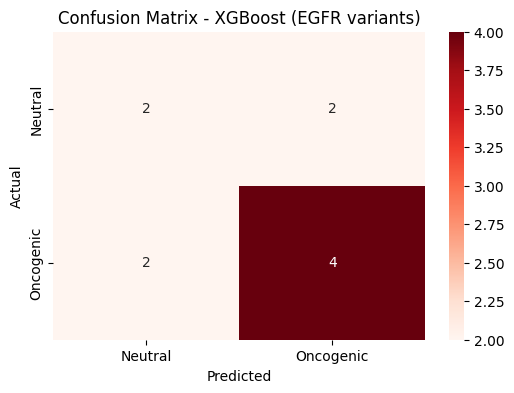

In [41]:
cm = confusion_matrix(y_test_EGFR, y_pred_EGFR)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (EGFR variants)')
plt.show()

### Find feature importances

In [42]:
# Define the best model 
best_model_EGFR = rf5_EGFR.best_estimator_

# Get feature names 
feature_names = best_model_EGFR.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model_EGFR.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

cat__Variant_Type_DEL                                      0.323009
cat__Variant_Type_SNP                                      0.170036
cat__Consequence_missense_variant                          0.129231
cat__Variant_Type_INS                                      0.120235
bin__In_Hotspot                                            0.105754
num__SIFT_Score                                            0.043320
num__Polyphen_Score                                        0.029350
num__n_func_sites                                          0.027493
num__n_protein_domains                                     0.024103
bin__IN_DOMAIN                                             0.011700
num__gnomAD_AF_log                                         0.008088
bin__has_gnomAD_AF                                         0.007681
bin__IN_FUNC_SITE                                          0.000000
bin__is_null_var_tsg                                       0.000000
bin__ncg_tsg                                    

## BRAF dataset

### Define the data

In [43]:
X_train_BRAF = X_train[X_train["Hugo_Symbol"] == 'BRAF']
X_test_BRAF = X_test[X_test["Hugo_Symbol"] == 'BRAF']

X_train_BRAF[impute_cols] = X_train_BRAF[impute_cols].fillna(-1)
X_test_BRAF[impute_cols] = X_test_BRAF[impute_cols].fillna(-1)

X_train_BRAF = X_train_BRAF.drop(columns="Hugo_Symbol")
X_test_BRAF = X_test_BRAF.drop(columns="Hugo_Symbol")

# Filter to match BRAF indices 
y_train_BRAF = y_train.loc[X_train_BRAF.index]
y_test_BRAF = y_test.loc[X_test_BRAF.index]

### Fit model to data

In [44]:
rf5_BRAF = rf5.fit(X_train_BRAF, y_train_BRAF.values.ravel()) 

print(rf5_BRAF.best_score_)
print(rf5_BRAF.best_params_)

print(f"The best F1-score (Macro) for the BRAF dataset: {rf5_BRAF.best_score_}")
print(f"The best hyperparameters: {rf5_BRAF.best_params_}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits
0.7941666666666667
{'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 30, 'clf__criterion': 'gini'}
The best F1-score (Macro) for the BRAF dataset: 0.7941666666666667
The best hyperparameters: {'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 30, 'clf__criterion': 'gini'}


### Predict classes and make classification report

In [45]:
# Predict classes for the BRAF dataset
y_pred_BRAF = rf5_BRAF.predict(X_test_BRAF)

# Predict probabilities
y_probs_BRAF = rf5_BRAF.predict_proba(X_test_BRAF)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_BRAF, y_pred_BRAF, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_BRAF, y_pred_BRAF))

Test F1-score (Macro): 0.9150

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.89      0.94         9

    accuracy                           0.92        13
   macro avg       0.90      0.94      0.92        13
weighted avg       0.94      0.92      0.93        13



### Create confusion matrix

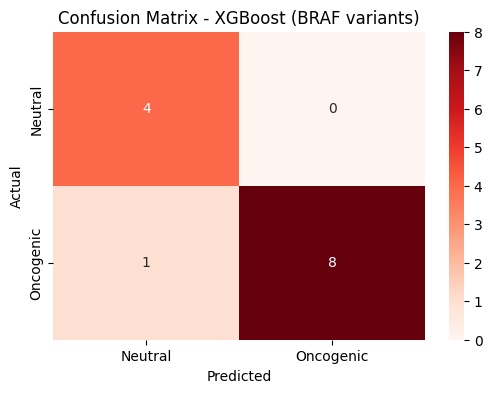

In [46]:
cm = confusion_matrix(y_test_BRAF, y_pred_BRAF)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (BRAF variants)')
plt.show()

### Find feature importances

In [47]:
# Define the best model 
best_model_BRAF = rf5_BRAF.best_estimator_

# Get feature names 
feature_names = best_model_BRAF.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model_BRAF.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

num__SIFT_Score                                            0.233238
bin__In_Hotspot                                            0.217032
num__Polyphen_Score                                        0.201956
bin__IN_DOMAIN                                             0.064642
cat__Consequence_missense_variant,splice_region_variant    0.039089
num__n_protein_domains                                     0.037993
bin__IN_FUNC_SITE                                          0.036314
cat__Variant_Type_SNP                                      0.035537
cat__Consequence_missense_variant                          0.034303
num__n_func_sites                                          0.032793
num__gnomAD_AF_log                                         0.020252
bin__has_gnomAD_AF                                         0.015062
cat__Variant_Type_INS                                      0.013533
cat__Variant_Type_ONP                                      0.006174
cat__Consequence_inframe_deletion               

## ERBB2 dataset 

### Define the data

In [48]:
X_train_ERBB2 = X_train[X_train["Hugo_Symbol"] == 'ERBB2']
X_test_ERBB2 = X_test[X_test["Hugo_Symbol"] == 'ERBB2']

X_train_ERBB2[impute_cols] = X_train_ERBB2[impute_cols].fillna(-1)
X_test_ERBB2[impute_cols] = X_test_ERBB2[impute_cols].fillna(-1)

X_train_ERBB2 = X_train_ERBB2.drop(columns="Hugo_Symbol")
X_test_ERBB2 = X_test_ERBB2.drop(columns="Hugo_Symbol")

# Filter to match ERBB2 indices 
y_train_ERBB2 = y_train.loc[X_train_ERBB2.index]
y_test_ERBB2 = y_test.loc[X_test_ERBB2.index]

### Fit model to data

In [49]:
rf5_ERBB2 = rf5.fit(X_train_ERBB2, y_train_ERBB2.values.ravel()) 

print(rf5_ERBB2.best_score_)
print(rf5_ERBB2.best_params_)

print(f"The best F1-score (Macro) for the ERBB2 dataset: {rf5_ERBB2.best_score_}")
print(f"The best hyperparameters: {rf5_ERBB2.best_params_}")

Fitting 10 folds for each of 20 candidates, totalling 200 fits
0.8573809523809522
{'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 4, 'clf__max_features': 'log2', 'clf__max_depth': None, 'clf__criterion': 'entropy'}
The best F1-score (Macro) for the ERBB2 dataset: 0.8573809523809522
The best hyperparameters: {'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 4, 'clf__max_features': 'log2', 'clf__max_depth': None, 'clf__criterion': 'entropy'}


### Predict classes and make classification report

In [50]:
# Predict classes for the ERBB2 dataset
y_pred_ERBB2 = rf5_ERBB2.predict(X_test_ERBB2)

# Predict probabilities
y_probs_ERBB2 = rf5_ERBB2.predict_proba(X_test_ERBB2)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_ERBB2, y_pred_ERBB2, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_ERBB2, y_pred_ERBB2))

Test F1-score (Macro): 0.8542

Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88         7
           1       1.00      0.71      0.83         7

    accuracy                           0.86        14
   macro avg       0.89      0.86      0.85        14
weighted avg       0.89      0.86      0.85        14



### Create confusion matrix

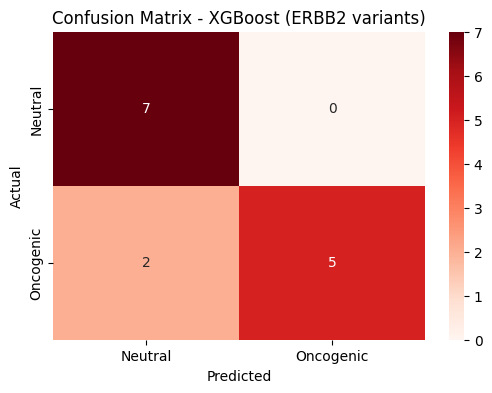

In [51]:
cm = confusion_matrix(y_test_ERBB2, y_pred_ERBB2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (ERBB2 variants)')
plt.show()

### Find feature importances

In [52]:
# Define the best model 
best_model_ERBB2 = rf5_ERBB2.best_estimator_

# Get feature names 
feature_names = best_model_ERBB2.named_steps['preprocessor'].get_feature_names_out()

# Find feature importances 
feat_importances = pd.Series(
    best_model_ERBB2.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(feat_importances)

num__Polyphen_Score                                        0.206250
num__SIFT_Score                                            0.167521
cat__Variant_Type_SNP                                      0.131230
bin__In_Hotspot                                            0.118695
bin__has_gnomAD_AF                                         0.105985
cat__Consequence_missense_variant                          0.093466
num__gnomAD_AF_log                                         0.061058
cat__Variant_Type_DEL                                      0.029196
cat__Consequence_protein_altering_variant                  0.026018
cat__Variant_Type_INS                                      0.020228
num__n_func_sites                                          0.018809
bin__IN_DOMAIN                                             0.011073
num__n_protein_domains                                     0.008114
cat__Consequence_missense_variant,splice_region_variant    0.002357
cat__Variant_Type_DNP                           